
# **APE 05 Grupo D**
-----------------
# **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Cristofer Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------


# **Tarea 1: Validación de Clase Invertida (Semana 4)**

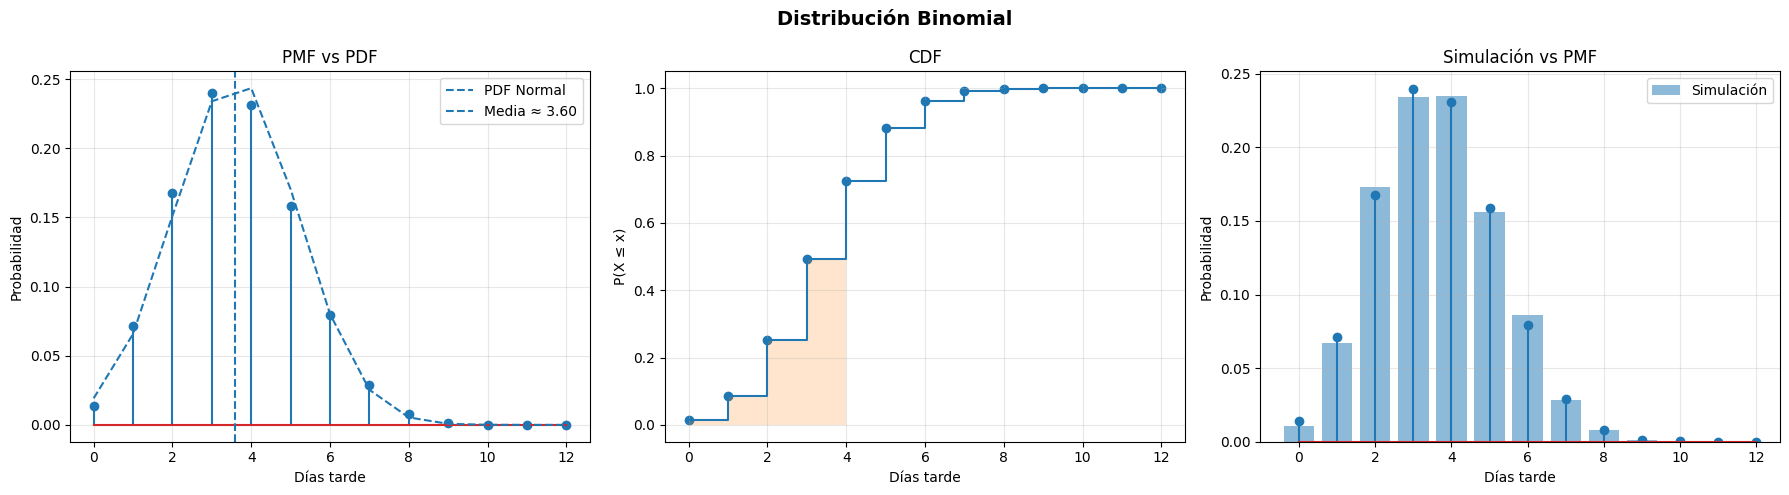

In [ ]:
# ==============================
# IMPORTACIONES
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

# ==============================
# PARÁMETROS
# ==============================

n = 12
p = 0.3

x = np.arange(0, n+1)

# ==============================
# FUNCIONES
# ==============================

pmf = binom.pmf(x, n, p)
cdf = binom.cdf(x, n, p)

# ==============================
# MEDIDAS
# ==============================

media = n * p
desviacion = np.sqrt(n * p * (1 - p))

# ==============================
# PDF APROXIMADA
# ==============================

pdf_aprox = norm.pdf(x, media, desviacion)

# ==============================
# SIMULACIÓN
# ==============================

sim = np.random.binomial(n, p, size=10000)
valores, counts = np.unique(sim, return_counts=True)
freq = counts / counts.sum()

# ==============================
# GRÁFICAS
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. PMF + PDF
_ = axes[0].stem(x, pmf)  # "_" evita que se imprima texto raro
axes[0].plot(x, pdf_aprox, linestyle='--', label="PDF Normal")
axes[0].axvline(media, linestyle='--', label=f"Media ≈ {media:.2f}")

axes[0].set_title("PMF vs PDF")
axes[0].set_xlabel("Días tarde")
axes[0].set_ylabel("Probabilidad")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. CDF
axes[1].step(x, cdf, where='post')
axes[1].scatter(x, cdf)
axes[1].fill_between(x, cdf, where=(x<=4), step='post', alpha=0.2)

axes[1].set_title("CDF")
axes[1].set_xlabel("Días tarde")
axes[1].set_ylabel("P(X ≤ x)")
axes[1].grid(alpha=0.3)

# 3. Simulación vs PMF
axes[2].bar(valores, freq, alpha=0.5, label="Simulación")
_ = axes[2].stem(x, pmf)

axes[2].set_title("Simulación vs PMF")
axes[2].set_xlabel("Días tarde")
axes[2].set_ylabel("Probabilidad")
axes[2].grid(alpha=0.3)
axes[2].legend()

# ==============================
# MOSTRAR
# ==============================

plt.suptitle("Distribución Binomial", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# PARTE 2: CÁLCULO DE PROBABILIDADES
# ==============================

# 1. Probabilidad exacta: exactamente 3 días tarde
p1 = binom.pmf(3, n, p)

# 2. Probabilidad acumulada: hasta 4 días tarde
p2 = binom.cdf(4, n, p)

# 3. Probabilidad en intervalo: entre 3 y 6 días
p3 = binom.cdf(6, n, p) - binom.cdf(2, n, p)

# 4. Probabilidad de valores altos: 6 o más días
p4 = 1 - binom.cdf(5, n, p)

# 5. Probabilidad de no llegar tarde nunca
p5 = binom.pmf(0, n, p)

# 6. Probabilidad de llegar tarde al menos una vez
p6 = 1 - p5

# 7. Probabilidad de eventos extremos (9 a 12 días)
p7 = binom.cdf(12, n, p) - binom.cdf(8, n, p)

# 8. Probabilidad alrededor de la media (4 a 5 días)
p8 = binom.cdf(5, n, p) - binom.cdf(3, n, p)

# Mostrar resultados
print("\n--- PROBABILIDADES ---")
print(f"P(X = 3) = {p1:.4f}")
print(f"P(X ≤ 4) = {p2:.4f}")
print(f"P(3 ≤ X ≤ 6) = {p3:.4f}")
print(f"P(X ≥ 6) = {p4:.4f}")
print(f"P(X = 0) = {p5:.4f}")
print(f"P(X ≥ 1) = {p6:.4f}")
print(f"P(9 ≤ X ≤ 12) = {p7:.4f}")
print(f"P(4 ≤ X ≤ 5) = {p8:.4f}")


--- PROBABILIDADES ---
P(X = 3) = 0.2397
P(X ≤ 4) = 0.7237
P(3 ≤ X ≤ 6) = 0.7086
P(X ≥ 6) = 0.1178
P(X = 0) = 0.0138
P(X ≥ 1) = 0.9862
P(9 ≤ X ≤ 12) = 0.0017
P(4 ≤ X ≤ 5) = 0.3896


# **Tarea 2: Cálculo Teórico y Simulación de Esperanza Matemática**

--- Variable Discreta (Binomial n=10, p=0.4) ---
Esperanza E[X]: 4.0
Varianza V[X]: 2.3999999999999995



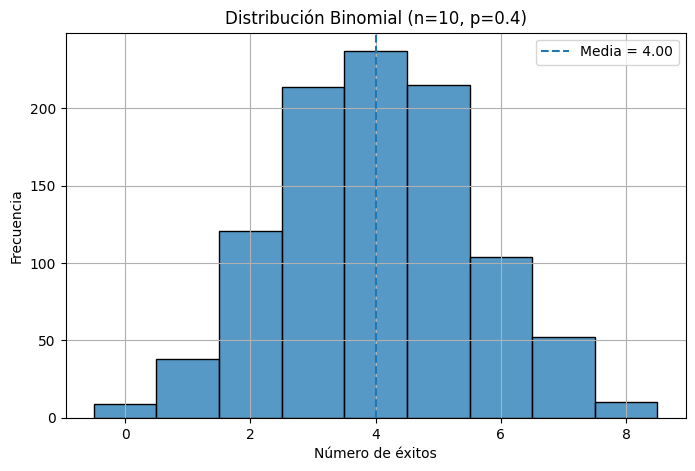

--- Variable Continua (Normal mu=50, sigma=5) ---
Esperanza E[X]: 50.0
Varianza V[X]: 25.0


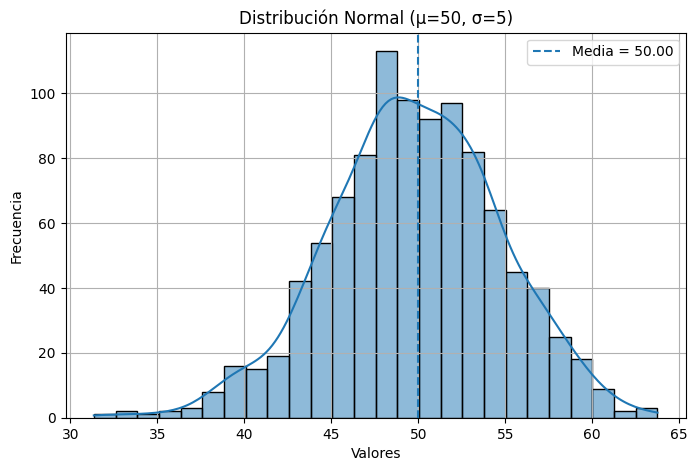

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom, norm

# 1. Variable Aleatoria Discreta (Distribución Binomial)
n_ensayos, p_exito = 10, 0.4
var_discreta = binom(n_ensayos, p_exito)

# Cálculo de Momentos Teóricos (Mean, Variance)
esperanza_d, varianza_d = var_discreta.stats(moments='mv')
print(f"--- Variable Discreta (Binomial n={n_ensayos}, p={p_exito}) ---")
print(f"Esperanza E[X]: {esperanza_d}")
print(f"Varianza V[X]: {varianza_d}\n")

# 🔹 Generar datos para histograma
data_binomial = var_discreta.rvs(size=1000)

# 🔹 Histograma bien organizado
plt.figure(figsize=(8,5))
sns.histplot(data_binomial, discrete=True)

plt.axvline(esperanza_d, linestyle='--', label=f'Media = {esperanza_d:.2f}')

plt.title('Distribución Binomial (n=10, p=0.4)')
plt.xlabel('Número de éxitos')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid()

plt.show()


# 2. Variable Aleatoria Continua (Distribución Normal)
mu, sigma = 50, 5  # Media y Desviación Estándar
var_continua = norm(loc=mu, scale=sigma)

esperanza_c, varianza_c = var_continua.stats(moments='mv')
print(f"--- Variable Continua (Normal mu={mu}, sigma={sigma}) ---")
print(f"Esperanza E[X]: {esperanza_c}")
print(f"Varianza V[X]: {varianza_c}")

# 🔹 Generar datos para histograma
data_normal = var_continua.rvs(size=1000)

# 🔹 Histograma bien organizado
plt.figure(figsize=(8,5))
sns.histplot(data_normal, kde=True)

plt.axvline(esperanza_c, linestyle='--', label=f'Media = {esperanza_c:.2f}')

plt.title('Distribución Normal (μ=50, σ=5)')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid()

plt.show()


# **Tarea 3: Hito del Proyecto - Análisis de Tendencia Central y Dispersión**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    Año  Semana Institución                        Unidad operativa Unicodigo  \
0  2021       1        IESS  000717-HOSPITAL DEL IESS DE ESMERALDAS   '000717   
1  2021       1        IESS        000929-HOSPITAL DE DURAN NIVEL I   '000929   
2  2021       1        IESS         000936-000936-CCQA SUR VALDIVIA   '000936   
3  2021       1        IESS   000939-CENTRO DE ESPECIALIDADES DAULE   '000939   
4  2021       1        IESS    001238-HOSPITAL DE BABAHOYO NIVEL II   '001238   

     Zona                                 Distrito Cod_Provincia   Provincia  \
0  ZONA 1                               ESMERALDAS           '08  ESMERALDAS   
1  ZONA 8                                    DURAN           '09      GUAYAS   
2  ZONA 8  PUNA, ESTUARIO DEL RIO GUAYAS, XIMENA 1           '09      GUAYAS   
3  ZONA 5                  DAULE,NOBOL,SANTA LUCIA           '09

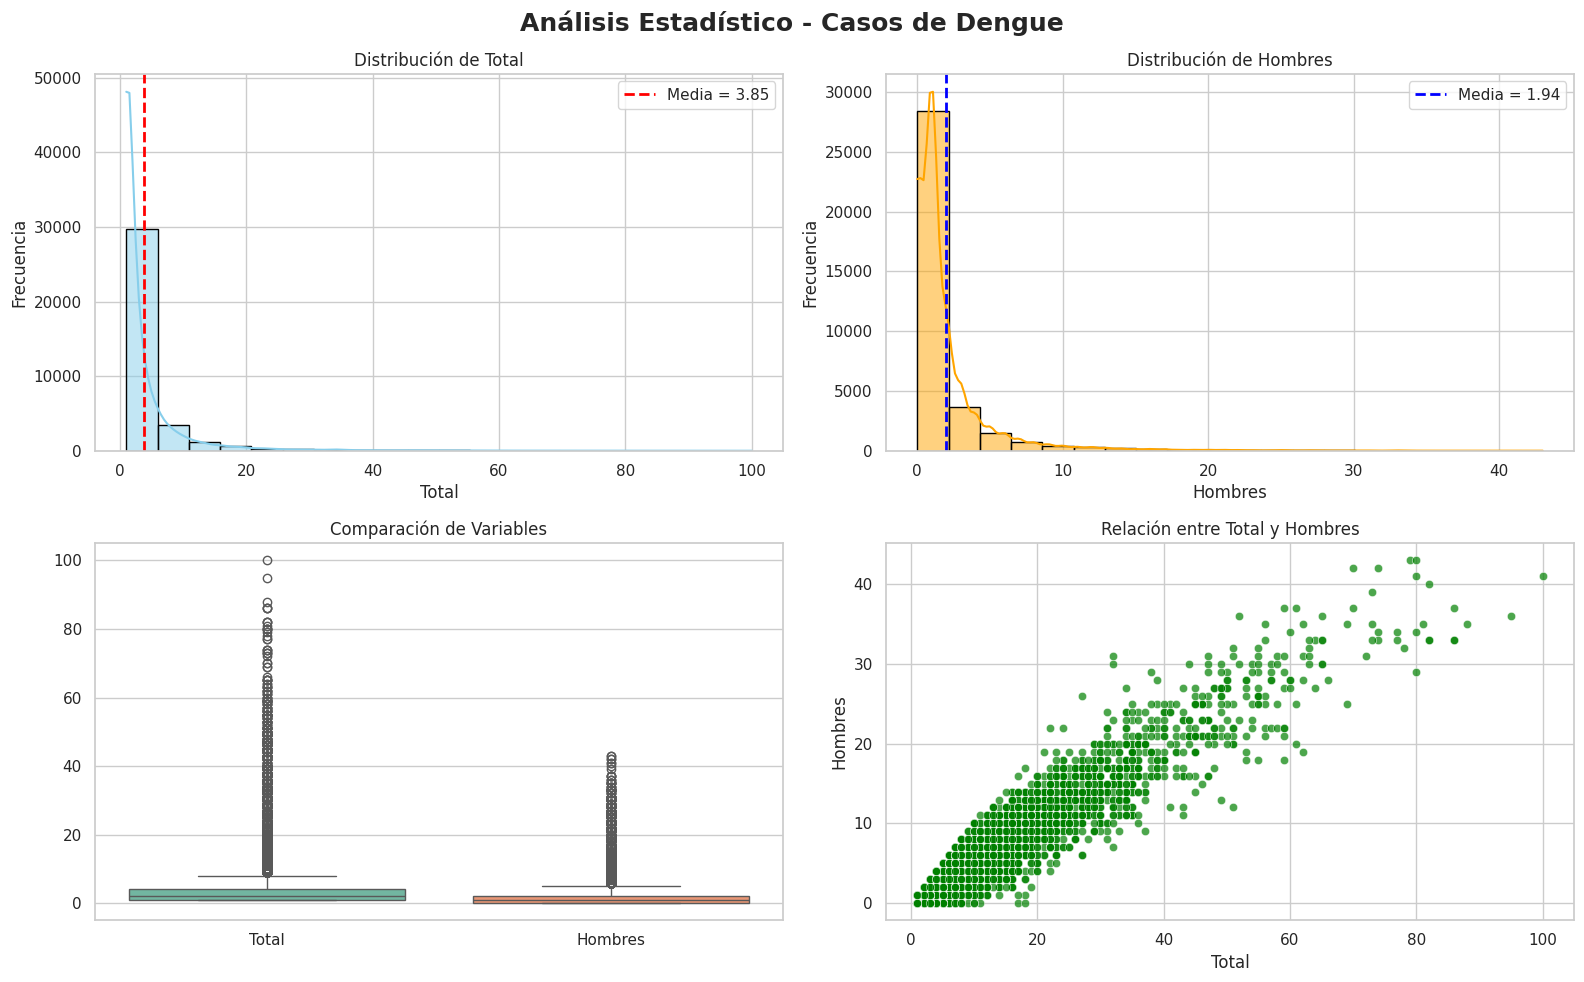

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# ESTILO GENERAL
# ==============================

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# ==============================
# CARGA DEL DATASET
# ==============================


print(df_regional.head())

# Limpiar nombres de columnas
df_regional.columns = df_regional.columns.str.strip()

# ==============================
# VARIABLES CUANTITATIVAS
# ==============================

variable1 = 'Total'
variable2 = 'Hombres'

# ==============================
# LIMPIEZA DE DATOS
# ==============================

df_regional[variable1] = pd.to_numeric(
    df_regional[variable1],
    errors='coerce'
)

df_regional[variable2] = pd.to_numeric(
    df_regional[variable2],
    errors='coerce'
)

df_limpio = df_regional[[variable1, variable2]].dropna()

# ==============================
# ESTADÍSTICOS
# ==============================

media1 = df_limpio[variable1].mean()
media2 = df_limpio[variable2].mean()

# Varianza muestral insesgada
varianza1 = df_limpio[variable1].var(ddof=1)
varianza2 = df_limpio[variable2].var(ddof=1)

# ==============================
# RESULTADOS
# ==============================

print("="*50)
print(" ANÁLISIS ESTADÍSTICO DEL DATASET REGIONAL ")
print("="*50)

print(f"\nVariable Analizada: {variable1}")
print(f"Media Muestral: {media1:.2f}")
print(f"Varianza Muestral: {varianza1:.2f}")

print(f"\nVariable Analizada: {variable2}")
print(f"Media Muestral: {media2:.2f}")
print(f"Varianza Muestral: {varianza2:.2f}")

# ==============================
# FIGURA GENERAL
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    'Análisis Estadístico - Casos de Dengue',
    fontsize=18,
    fontweight='bold'
)

# ==============================
# HISTOGRAMA TOTAL
# ==============================

sns.histplot(
    df_limpio[variable1],
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='black',
    ax=axes[0,0]
)

axes[0,0].axvline(
    media1,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Media = {media1:.2f}'
)

axes[0,0].set_title(f'Distribución de {variable1}')
axes[0,0].set_xlabel(variable1)
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend()

# ==============================
# HISTOGRAMA HOMBRES
# ==============================

sns.histplot(
    df_limpio[variable2],
    bins=20,
    kde=True,
    color='orange',
    edgecolor='black',
    ax=axes[0,1]
)

axes[0,1].axvline(
    media2,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Media = {media2:.2f}'
)

axes[0,1].set_title(f'Distribución de {variable2}')
axes[0,1].set_xlabel(variable2)
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].legend()

# ==============================
# BOXPLOT
# ==============================

sns.boxplot(
    data=df_limpio[[variable1, variable2]],
    palette='Set2',
    ax=axes[1,0]
)

axes[1,0].set_title('Comparación de Variables')

# ==============================
# DISPERSIÓN
# ==============================

sns.scatterplot(
    x=df_limpio[variable1],
    y=df_limpio[variable2],
    color='green',
    alpha=0.7,
    ax=axes[1,1]
)

axes[1,1].set_title(
    f'Relación entre {variable1} y {variable2}'
)

axes[1,1].set_xlabel(variable1)
axes[1,1].set_ylabel(variable2)

# ==============================
# AJUSTE FINAL
# ==============================

plt.tight_layout()
plt.show()

# **Preguntas de Control.**

## **¿Cuál es la diferencia matemática y conceptual entre la esperanza matemática teórica calculada a partir de un modelo de probabilidad (ej. binom.stats()) y la media muestral calculada de un DataFrame de pandas?**



In [ ]:
import pandas as pd

# Crear tabla comparativa
tabla = pd.DataFrame({
    'ASPECTO': [
        'Naturaleza',
        'Origen',
        'Fórmula general',
        '¿Depende de los datos?',
        'Uso',
        'Precisión',
        'Error'
    ],

    'ESPERANZA MATEMÁTICA E[X]': [
        'Parámetro teórico del modelo probabilístico',
        'Se obtiene de una distribución de probabilidad conocida',
        'Promedio ponderado por probabilidades',
        'No depende de datos observados',
        'Modelos teóricos, inferencia y simulaciones',
        'Representa el valor verdadero bajo el modelo',
        'No tiene error muestral'
    ],

    'MEDIA MUESTRAL x̄': [
        'Estadístico calculado a partir de datos',
        'Se calcula a partir de una muestra observada',
        'Promedio aritmético simple',
        'Sí depende de los datos recolectados',
        'Análisis descriptivo de datos reales',
        'Es una estimación del valor verdadero',
        'Tiene error de muestreo'
    ]
})


display(tabla)

,ASPECTO,ESPERANZA MATEMÁTICA E[X],MEDIA MUESTRAL x̄
0,Naturaleza,Parámetro teórico del modelo probabilístico,Estadístico calculado a partir de datos
1,Origen,Se obtiene de una distribución de probabilidad...,Se calcula a partir de una muestra observada
2,Fórmula general,Promedio ponderado por probabilidades,Promedio aritmético simple
3,¿Depende de los datos?,No depende de datos observados,Sí depende de los datos recolectados
4,Uso,"Modelos teóricos, inferencia y simulaciones",Análisis descriptivo de datos reales
5,Precisión,Representa el valor verdadero bajo el modelo,Es una estimación del valor verdadero
6,Error,No tiene error muestral,Tiene error de muestreo


## **Demuestre teóricamente, utilizando las propiedades de la esperanza, por qué la varianza se puede reescribir como:**

$$
V[X] = E[X^2] - (E[X])^2
$$


La varianza de una variable aleatoria \(X\) se define como:

$$
V[X] = E[(X - E[X])^2]
$$

Aplicando el cuadrado del binomio:

$$
(X - E[X])^2 = X^2 - 2X(E[X]) + (E[X])^2
$$

Sustituyendo en la definición de varianza:

$$
V[X] = E[X^2 - 2X(E[X]) + (E[X])^2]
$$

Aplicando la propiedad de linealidad de la esperanza:

$$
V[X] = E[X^2] - 2E[X(E[X])] + E[(E[X])^2]
$$

Como \(E[X]\) es una constante:

$$
E[X(E[X])] = E[X] \cdot E[X]
$$

y

$$
E[(E[X])^2] = (E[X])^2
$$

Entonces:

$$
V[X] = E[X^2] - 2(E[X])^2 + (E[X])^2
$$

Finalmente:

$$
V[X] = E[X^2] - (E[X])^2
$$

## **Si la varianza calculada en su variable regional es inusualmente alta, ¿qué implicaciones prácticas tiene esto sobre la confiabilidad de la media como predictor del comportamiento de esos datos en la región de Loja?**

Si la varianza es muy alta, significa que hay una gran dispersión, y utilizar la
media para tomar decisiones en la región de Loja podría llevar a errores graves
de planificación.
1. La media deja de representar el escenario "típico"
Una varianza alta indica que los valores extremos están empujando la media
hacia un punto que quizás nadie experimente.
* Ejemplo Clima en Loja: Si analizamos la precipitación mensual en
distintas zonas de la provincia de Loja, una media de 70 mm podría
sugerir un clima templado y húmedo constante. Sin embargo, con una
varianza alta, la realidad podría ser que meses sufren de sequías extremas
mientras otros enfrentan lluvias torrenciales. Predecir o prepararse
basándose en los 70 mm sería un desastre para la agricultura.
2. Aumenta el riesgo en la toma de decisiones
Si utilizas un predictor poco confiable, el riesgo de que tus estrategias fallen
aumenta considerablemente.
* Ejemplo de la Economía Agrícola en Loja: Digamos que la variable es el
rendimiento anual de las fincas. Si la varianza es alta, significa que hay
FEIRNNR - Carrera de Computación
fincas con una producción excepcional y otras con pérdidas graves. Si una
política pública o un banco otorga créditos basándose en el "ingreso
medio", terminará sobreendeudado a los productores pequeños y
subfinanciando a los grandes

## **Revise el parámetro ddof de la función var() en Pandas. ¿Qué ocurre con el estimador de la varianza si establecemos ddof=0 y en qué escenario específico de población poblacional esto sería matemáticamente correcto?**

Si se fija ddof=0, la función divide entre N y calcula la varianza poblacional “sin
corrección de Bessel”, que coincide con la definición matemática correcta cuando
sus datos representan toda la población y no solo una muestra. En ese escenario,
usar ddof=0 es correcto; si los datos son solo una muestra, ddof=1 suele ser el
estimador apropiado de la varianza poblacional.

## **Observe el histograma generado en la Tarea 3.** ¿De qué manera el cálculo combinado de la esperanza matemática (media) y la varianza apoyan en la identificación estadística de valores atípicos (outliers) para la posterior limpieza de su Proyecto Integrador

En el histograma generado a partir del dataset regional de dengue, la esperanza matemática (media muestral) y la varianza permitieron analizar el comportamiento de la variable Total, correspondiente al número total de casos registrados.

La media muestral representa el promedio de casos de dengue presentes en el conjunto de datos. En la gráfica, esta se observa mediante una línea vertical que indica el punto central donde se concentra la mayor parte de los registros. Esto facilita identificar cuál es el comportamiento promedio de los casos reportados en las diferentes semanas y zonas analizadas.

Por otra parte, la varianza muestral mide el nivel de dispersión de los datos respecto a esa media. En el análisis realizado, algunos valores del histograma aparecen alejados de la concentración principal de frecuencias, evidenciando posibles valores atípicos (outliers). Estos registros podrían corresponder a semanas epidemiológicas con brotes inusuales, errores de digitación o inconsistencias en la recolección de datos.

El cálculo conjunto de la media y la varianza permitió:

* Detectar registros extremadamente altos o bajos respecto al promedio general.
* Identificar posibles anomalías en ciertas provincias, cantones o semanas epidemiológicas.
* Evaluar si la distribución de casos presenta alta dispersión.
* Facilitar la limpieza del dataset antes de aplicar análisis más avanzados.


Además, al observar que algunos datos se encuentran considerablemente alejados de la media, es posible considerar dichos registros para revisión estadística, ya que pueden influir en la interpretación general del comportamiento del dengue en la región estudiada.

Por lo tanto, el histograma junto con la media y la varianza constituyen herramientas fundamentales para comprender la distribución de los casos de dengue y mejorar la calidad del análisis del Proyecto Integrador.